<a href="https://colab.research.google.com/github/RuanCarlosDaSilvaLima/Estudos-Inteligencia-artificial/blob/main/Lista_de_exercicios_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Passo 1 -
Preparando o Colab

In [2]:
!pip install torch numpy scikit-learn matplotlib pandas

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("GPU disponível:", torch.cuda.is_available())

torch: 2.11.0+cpu
numpy: 2.1.3
GPU disponível: False


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device utilizado:", device)

Device utilizado: cpu


Passo 2 - Baixando o Auto MPG

In [19]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

colunas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    header=None,
    names=colunas,
    na_values="?"
)

print("Formato inicial:", df.shape)

df.head()

Formato inicial: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


removendo os horsepower com valores ausentes

In [20]:
# Remover linhas com valores ausentes
df = df.dropna().copy()

print("Formato após remover missing:", df.shape)

Formato após remover missing: (392, 9)


Passo 3 - Separar X e y

In [21]:
# Variável alvo: MPG
y = df["mpg"].to_numpy(dtype=np.float64)

# Features numéricas
features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

X = df[features].to_numpy(dtype=np.float64)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nPrimeiras linhas de X:")
print(X[:5])

print("\nPrimeiros valores de y:")
print(y[:5])

Formato de X: (392, 6)
Formato de y: (392,)

Primeiras linhas de X:
[[   8.   307.   130.  3504.    12.    70. ]
 [   8.   350.   165.  3693.    11.5   70. ]
 [   8.   318.   150.  3436.    11.    70. ]
 [   8.   304.   150.  3433.    12.    70. ]
 [   8.   302.   140.  3449.    10.5   70. ]]

Primeiros valores de y:
[18. 15. 18. 16. 17.]


Passo 4 - Criando os tensores

In [22]:
X_t = torch.tensor(
    X,
    dtype=torch.float64,
    device=device
)

y_t = torch.tensor(
    y,
    dtype=torch.float64,
    device=device
)

print("X_t:", X_t.shape)
print("y_t:", y_t.shape)
print("Device de X_t:", X_t.device)
print("Device de y_t:", y_t.device)

X_t: torch.Size([392, 6])
y_t: torch.Size([392])
Device de X_t: cpu
Device de y_t: cpu


Passo 5 — Montar a matriz com o intercepto

In [24]:
# Criando a coluna de 1's para o intercepto
ones = torch.ones(
    (X_t.shape[0], 1),
    dtype=torch.float64,
    device=device
)

# Matriz X com intercepto
X_barra = torch.cat(
    [ones, X_t],
    dim=1
)

print("Formato de X_barra:", X_barra.shape)
print("\nPrimeira linha:")
print(X_barra[0])

Formato de X_barra: torch.Size([392, 7])

Primeira linha:
tensor([1.0000e+00, 8.0000e+00, 3.0700e+02, 1.3000e+02, 3.5040e+03, 1.2000e+01,
        7.0000e+01], dtype=torch.float64)


Passo 6 - Equação normal β=(XˉTXˉ)−1XˉTy

In [25]:
# Calculando X^T X
XtX = X_barra.T @ X_barra

# Calculando X^T y
Xty = X_barra.T @ y_t

# Equação Normal
beta = torch.linalg.solve(XtX, Xty)

print("Coeficientes beta:")
print(beta)

Coeficientes beta:
tensor([-1.4535e+01, -3.2986e-01,  7.6784e-03, -3.9136e-04, -6.7946e-03,
         8.5273e-02,  7.5337e-01], dtype=torch.float64)


Passo 7 - Calcular as previsões


In [26]:
# Previsões
y_pred = X_barra @ beta

print("Primeiras 10 previsões:")
print(y_pred[:10])

print("\nPrimeiros 10 valores reais:")
print(y_t[:10])

Primeiras 10 previsões:
tensor([15.0829, 14.0726, 15.5363, 15.5345, 15.2864, 10.1354, 10.1452, 10.2824,
         9.7538, 13.0474], dtype=torch.float64)

Primeiros 10 valores reais:
tensor([18., 15., 18., 16., 17., 15., 14., 14., 14., 15.], dtype=torch.float64)


Passo 8 - MSE e RMSE com NumPy

In [32]:
# Converter as previsões para NumPy
y_pred_np = y_pred.detach().cpu().numpy()

# Erro
erro = y - y_pred_np

# MSE e RMSE manual
mse_numpy = np.mean(erro ** 2)
rmse_numpy = np.sqrt(mse_numpy)

print("MSE (NumPy):", mse_numpy)
print("RMSE (NumPy):", rmse_numpy)

MSE (NumPy): 11.590170981415229
RMSE (NumPy): 3.404434017779641


Passo 9 - MSE e RMSE com PyTorch

In [33]:
# Erro entre valores reais e previstos
erro_t = y_t - y_pred

# MSE
mse_torch = torch.mean(erro_t ** 2)

# RMSE
rmse_torch = torch.sqrt(mse_torch)

print("MSE (PyTorch):", mse_torch.item())
print("RMSE (PyTorch):", rmse_torch.item())

MSE (PyTorch): 11.590170981415229
RMSE (PyTorch): 3.404434017779641


Passo 10 - MSE e RMSE com sklearn

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Modelo de referência
modelo_sklearn = LinearRegression()

# Treinar
modelo_sklearn.fit(X, y)

# Previsões
y_pred_sklearn = modelo_sklearn.predict(X)

# MSE
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# RMSE
rmse_sklearn = np.sqrt(mse_sklearn)

print("MSE (sklearn):", mse_sklearn)
print("RMSE (sklearn):", rmse_sklearn)

MSE (sklearn): 11.590170981415225
RMSE (sklearn): 3.4044340177796406


Passo 11 — Comparação entre NumPy, PyTorch e sklearn

In [35]:
print("===== COMPARAÇÃO =====")

print(f"NumPy   - MSE: {mse_numpy:.10f} | RMSE: {rmse_numpy:.10f}")
print(f"PyTorch - MSE: {mse_torch.item():.10f} | RMSE: {rmse_torch.item():.10f}")
print(f"sklearn - MSE: {mse_sklearn:.10f} | RMSE: {rmse_sklearn:.10f}")

===== COMPARAÇÃO =====
NumPy   - MSE: 11.5901709814 | RMSE: 3.4044340178
PyTorch - MSE: 11.5901709814 | RMSE: 3.4044340178
sklearn - MSE: 11.5901709814 | RMSE: 3.4044340178


Passo 12 — Previsão do carro

In [36]:
# Características do carro
carro_novo = np.array([[
    4,     # cylinders
    140,   # displacement
    90,    # horsepower
    2500,  # weight
    15,    # acceleration
    80     # model_year
]], dtype=np.float64)

# Converter para PyTorch
carro_novo_t = torch.tensor(
    carro_novo,
    dtype=torch.float64,
    device=device
)

# Adicionar o intercepto
carro_novo_barra = torch.cat([
    torch.ones((1, 1), dtype=torch.float64, device=device),
    carro_novo_t
], dim=1)

# Previsão
previsao_carro = carro_novo_barra @ beta

print("MPG previsto:", previsao_carro.item())

MPG previsto: 29.746999696487016


Passo 13 — Gráfico: valores reais × previstos

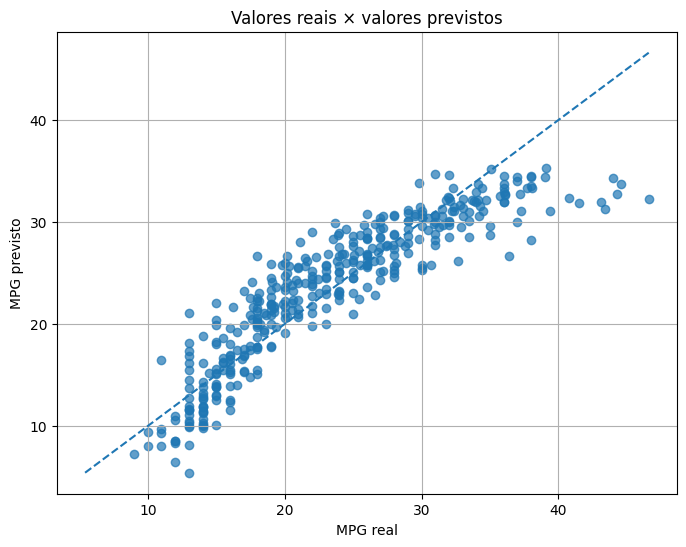

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(y, y_pred_np, alpha=0.7)

# Linha ideal: previsão = valor real
min_val = min(y.min(), y_pred_np.min())
max_val = max(y.max(), y_pred_np.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("MPG real")
plt.ylabel("MPG previsto")
plt.title("Valores reais × valores previstos")

plt.grid(True)
plt.show()

Passo 14 — Análise final

A regressão linear foi implementada pela Equação Normal, sem utilizar o
`sklearn` para o ajuste do modelo.

Os resultados obtidos foram:

- MSE com NumPy: 11.5901709814
- RMSE com NumPy: 3.4044340178
- MSE com PyTorch: 11.5901709814
- RMSE com PyTorch: 3.4044340178
- MSE com sklearn: 11.5901709814
- RMSE com sklearn: 3.4044340178

Os resultados de NumPy, PyTorch e sklearn foram praticamente idênticos,
confirmando que a implementação manual da regressão pela Equação Normal
está correta.

O RMSE de aproximadamente 3,40 MPG indica que o erro típico das previsões
é de cerca de 3,4 MPG.

No gráfico de valores reais versus previstos, observa-se que a maior parte
dos pontos está próxima da linha ideal. Entretanto, para valores mais altos
de MPG, o modelo apresenta uma tendência de subestimar algumas previsões.

Para o carro com 4 cilindros, displacement igual a 140, 90 horsepower,
peso de 2500, aceleração de 15 e model_year igual a 80, o modelo previu:

**29,75 MPG aproximadamente.**